<a href="https://colab.research.google.com/github/siwell24/Portofolio-Wildan/blob/main/Modul%207%3A%20Advanced%20Spatial%20%26%20Tabular%20Merging%20%26%20Multi-Variable%20Risk%20Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INPUT GEOJSON/SHP

In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

nama_file = "/content/drive/MyDrive/Learning Phyton/Provinsi Indonesia/38 Provinsi Indonesia - Kabupaten.json"
indonesia = gpd.read_file (nama_file)
provinsi_aceh = indonesia[indonesia["WADMPR"] == "Aceh"]

# INPUT DATA LAPORAN

In [17]:
data_statistik_internal = {
    "WADMKK" : [
        "Aceh Tengah",
        "Bener Meriah",
        "Aceh Besar",
        "Kota Banda Aceh",
        "Gayo Lues",
    ],
    "Estimasi_Kerugian_JutaIDR": [
        15000,
        8500,
        22000,
        31000,
        4200
        ],
    "Jumlah_Pengungsi": [
        1200,
        800,
        2500,
        4100,
        350
    ],
    "Indeks_Resiko": [
        "Rendah",
        "Sedang",
        "Tinggi",
        "Sangat Tinggi",
        "Sangat Tinggi",
    ]
}



# BUILD UTM ZONE ACEH

In [18]:
aceh_utm = provinsi_aceh.estimate_utm_crs()
provinsi_aceh_utm = provinsi_aceh.to_crs(aceh_utm)
print (aceh_utm)

EPSG:32647


# MERGE

In [19]:
df_statistik = gpd.GeoDataFrame(data_statistik_internal)
provinsi_aceh_risiko = provinsi_aceh_utm.merge(df_statistik, on="WADMKK", how="left")

# PLOT PETA ESTIMATE KERUGIAN

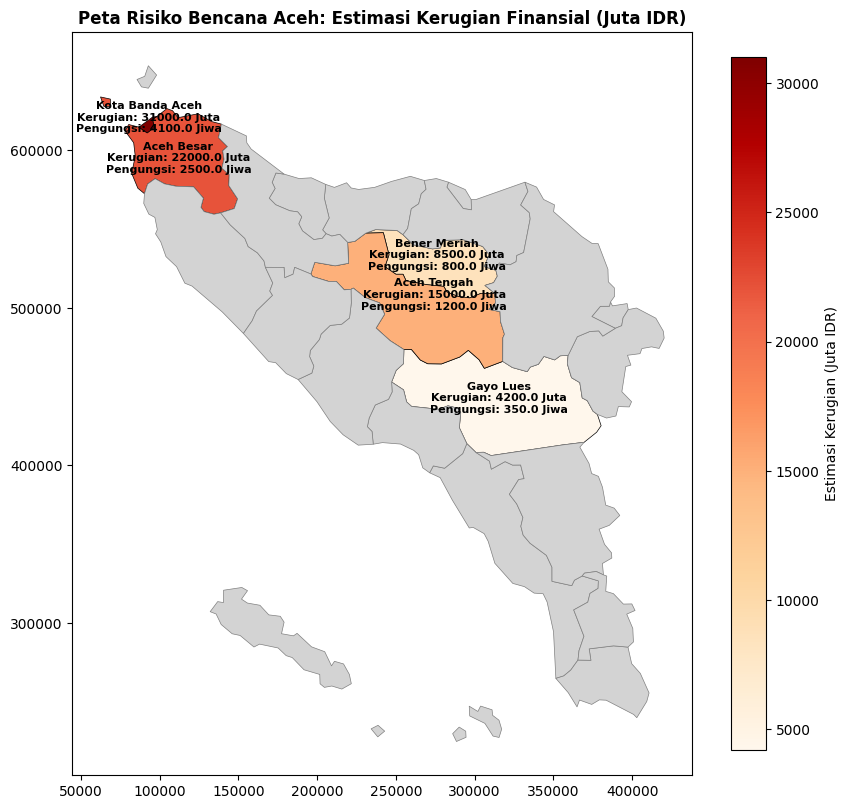

In [60]:
fig, ax = plt.subplots(figsize=(10,10))

provinsi_aceh_risiko.plot(
    column="Estimasi_Kerugian_JutaIDR",
    cmap = "OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    legend_kwds={
        "label": "Estimasi Kerugian (Juta IDR)",
        "orientation": "vertical",
        "shrink": 0.9,
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "grey",
        "label": "Tidak Ada Data Kerugian"
    },
)
for idx, row in provinsi_aceh_risiko.iterrows():
  if pd.notna(row["Estimasi_Kerugian_JutaIDR"]) :
    titik_tengah = row.geometry.representative_point()
    teks_label=(
        f"{row['WADMKK']}\n"
        f"Kerugian: {row['Estimasi_Kerugian_JutaIDR']} Juta\n"
        f"Pengungsi: {row['Jumlah_Pengungsi']} Jiwa\n"
    )
    ax.text(
        titik_tengah.x,
        titik_tengah.y,
        teks_label,
        fontsize=8,
        ha="center",
        va="center",
        weight="bold",
        color="black"
    )
plt.title(
    "Peta Risiko Bencana Aceh: Estimasi Kerugian Finansial (Juta IDR)",
    fontsize=12,
    weight="bold",
)
plt.show()

# PLOT PETA INDEKS RISIKO

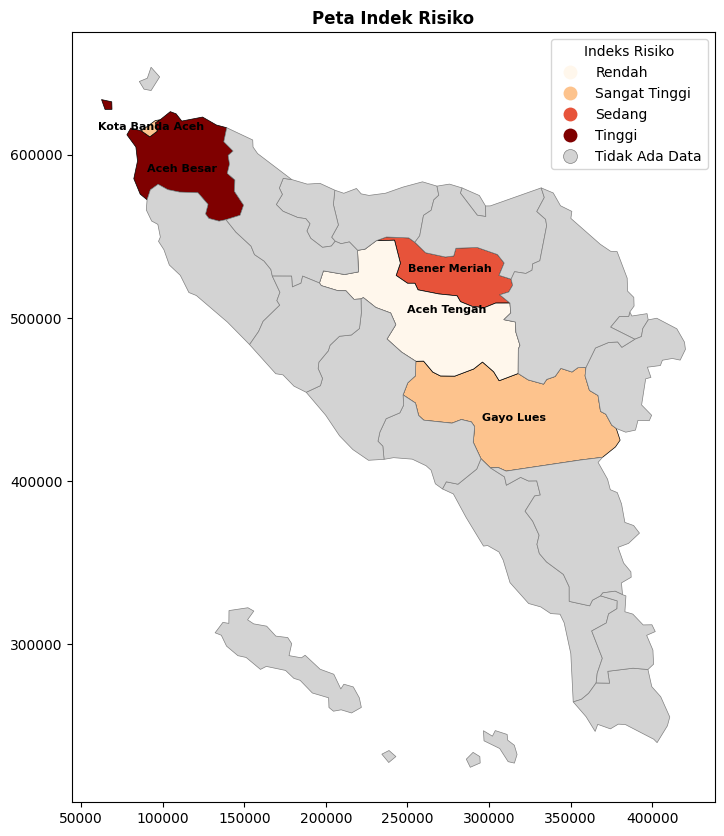

In [51]:
fig, ax = plt.subplots(figsize=(10,10))

provinsi_aceh_risiko.plot(
    column="Indeks_Resiko",
    cmap = "OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    legend_kwds={
        "title": "Indeks Risiko"
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "grey",
        "label": "Tidak Ada Data"
    },
)
for idx, row in provinsi_aceh_risiko.iterrows():
  if pd.notna(row["Estimasi_Kerugian_JutaIDR"]) :
    titik_tengah = row.geometry.representative_point()
    ax.text(
        titik_tengah.x,
        titik_tengah.y,
        f"{row['WADMKK']}",
        fontsize=8,
        ha="center",
        va="center",
        weight="bold",
        color="black",
    )
plt.title(
    "Peta Indek Risiko",
    fontsize=12,
    weight="bold",
)
plt.show()